# FoodDelivery.csv - Exploratory Data Analysis

## Table of Contents
1. [Setup & Load Data](#1)
2. [Structural Overview](#2)
3. [Missing Values](#3)
4. [Duplicates](#4)
5. [Data Cleaning](#5)
6. [Coordinate Cleaning & Distance Feature](#6)
7. [Missing Value Treatment](#7)
8. [Feature Engineering](#8)
9. [Numeric Features](#9)
10. [Categorical Features](#10)
11. [Outlier Detection](#11)
12. [Association Matrix (Numeric + Categorical)](#12)
13. [Categorical vs Numeric](#13)
14. [Missingness Pattern](#14)
15. [Target Variable](#15)
16. [Summary & Cleaning Plan](#16)
17. [Encoding & Train/Test Split](#17)
18. [Scaling](#18)
19. [Model Training & Comparison](#19)
20. [Model Evaluation](#20)

<a id='1'></a>
## 1. Setup & Load Data
- Import pandas, numpy, matplotlib, seaborn
- Load FoodDelivery.csv into a DataFrame

In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

%load_ext autoreload
%autoreload 2

%pip install scikit-learn

%pip install global-land-mask
%pip install requests
%pip install geopy
%pip install haversine

project_root = Path.cwd().parent  # notebooks/ -> DeliveryETA/
sys.path.append(str(project_root))

from src.extract.extractingData import readData

sns.set_theme(style="whitegrid")

deliveryDataFrame = readData()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


<a id='2'></a>
## 2. Structural Overview
- df.shape
- df.columns and df.dtypes
- df.head() / df.tail()
- df.info()

In [174]:

print(f"{deliveryDataFrame.shape[0]} rows x {deliveryDataFrame.shape[1]} columns" )

print('\n======= Types =======\n')
dtypes_df = pd.DataFrame(deliveryDataFrame.dtypes, columns=['Data Type'])
display(dtypes_df)

print('\n======= Head =======\n')
display(deliveryDataFrame.head())
print('\n======= Tail =======\n')
display(deliveryDataFrame.tail())

print('\n======= Random Sample =======\n')
sample = deliveryDataFrame.sample(n=20)
display(sample)

print('\n======= Head =======\n')

cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
         'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 
         'Type_of_vehicle', 'multiple_deliveries', 'Festival',
           'City', 'Time_taken(min)']
for column in cols:
    print(f'+++ {column} +++')
    for value in deliveryDataFrame[column].unique():
        print(f'{value}', end= '\t')
    print('\n')


45593 rows x 20 columns

======= Types =======



,Data Type
ID,str
Delivery_person_ID,str
Delivery_person_Age,str
Delivery_person_Ratings,str
Restaurant_latitude,float64
Restaurant_longitude,float64
Delivery_location_latitude,float64
Delivery_location_longitude,float64
Order_Date,str
Time_Orderd,str



======= Head =======



,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30



======= Tail =======



,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26
45592,0x5fb2,RANCHIRES09DEL02,23,4.9,23.351058,85.325731,23.431058,85.405731,02-03-2022,17:10:00,17:15:00,conditions Fog,Medium,2,Snack,scooter,1,No,Metropolitian,(min) 36



======= Random Sample =======



,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
35080,0xa043,VADRES07DEL03,33,4.4,0.000000,0.000000,0.030000,0.030000,19-03-2022,20:45:00,20:55:00,conditions Windy,Jam,0,Meal,motorcycle,2,No,Urban,(min) 40
45034,0xcbf0,ALHRES07DEL01,23,4.7,25.449659,81.839744,25.559659,81.949744,16-02-2022,18:45:00,18:55:00,conditions Fog,Medium,2,Buffet,scooter,1,No,Urban,(min) 33
5665,0x68be,CHENRES03DEL03,27,4.6,13.091809,80.219104,13.181809,80.309104,25-03-2022,17:35:00,17:45:00,conditions Cloudy,Medium,0,Drinks,motorcycle,1,No,Urban,(min) 34
2464,0xc28,CHENRES19DEL02,20,5,12.986047,80.218114,13.036047,80.268114,15-03-2022,21:10:00,21:25:00,conditions Stormy,Jam,1,Snack,motorcycle,NaN,No,Metropolitian,(min) 16
30170,0xa7dd,CHENRES01DEL01,33,4.9,13.005801,80.250744,13.045801,80.290744,05-03-2022,12:55:00,13:10:00,conditions Cloudy,High,1,Buffet,motorcycle,1,No,Metropolitian,(min) 39
19879,0x95b,HYDRES19DEL02,NaN,NaN,17.458998,78.500366,17.478998,78.520366,30-03-2022,NaN,12:10:00,conditions Sandstorms,High,0,Drinks,motorcycle,2,No,Metropolitian,(min) 49
35169,0xc057,ALHRES06DEL01,28,4.6,0.000000,0.000000,0.010000,0.010000,17-02-2022,09:30:00,09:40:00,conditions Fog,Low,1,Buffet,scooter,1,No,Urban,(min) 14
7015,0x9c54,CHENRES13DEL03,23,4.7,13.027018,80.254791,13.057018,80.284791,09-03-2022,19:30:00,19:40:00,conditions Fog,Jam,2,Snack,scooter,0,No,Urban,(min) 28
18123,0x39d9,SURRES12DEL02,24,4.8,21.183434,72.814492,21.233434,72.864492,01-03-2022,18:55:00,19:05:00,conditions Stormy,Medium,1,Snack,motorcycle,0,No,Metropolitian,(min) 28
38658,0x3724,MYSRES13DEL02,38,4.6,12.310972,76.659264,12.360972,76.709264,09-03-2022,19:45:00,20:00:00,conditions Sandstorms,Jam,1,Drinks,motorcycle,0,No,Metropolitian,(min) 29



======= Head =======

+++ Delivery_person_Age +++
37	34	23	38	32	22	33	35	36	21	24	29	25	31	27	26	20	NaN 	28	39	30	15	50	

+++ Delivery_person_Ratings +++
4.9	4.5	4.4	4.7	4.6	4.8	4.2	4.3	4	4.1	5	3.5	NaN 	3.8	3.9	3.7	2.6	2.5	3.6	3.1	2.7	1	3.2	3.3	6	3.4	2.8	2.9	3	

+++ Weatherconditions +++
conditions Sunny	conditions Stormy	conditions Sandstorms	conditions Cloudy	conditions Fog	conditions Windy	conditions NaN	

+++ Road_traffic_density +++
High 	Jam 	Low 	Medium 	NaN 	

+++ Vehicle_condition +++
2	0	1	3	

+++ Type_of_order +++
Snack 	Drinks 	Buffet 	Meal 	

+++ Type_of_vehicle +++
motorcycle 	scooter 	electric_scooter 	bicycle 	

+++ multiple_deliveries +++
0	1	3	NaN 	2	

+++ Festival +++
No 	Yes 	NaN 	

+++ City +++
Urban 	Metropolitian 	Semi-Urban 	NaN 	

+++ Time_taken(min) +++
(min) 24	(min) 33	(min) 26	(min) 21	(min) 30	(min) 40	(min) 32	(min) 34	(min) 46	(min) 23	(min) 20	(min) 41	(min) 15	(min) 36	(min) 39	(min) 18	(min) 38	(min) 47	(min) 12	(min) 22	(min) 25	(min) 35	(min) 10	(

<a id='3'></a>
## 3. Missing Values Analysis
- df.isna().sum()
- Percentage missing per column
- Missingness heatmap: sns.heatmap(df.isna(), cbar=False)

======= missing values count  ========
ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions               616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64
======= missing values percentages ========
ID                             0.00
Delivery_person_ID             0.00
Delivery_person_Age            4.07
Delivery_person_Ratings        4.18
Restaurant_latitude            0.00
Rest

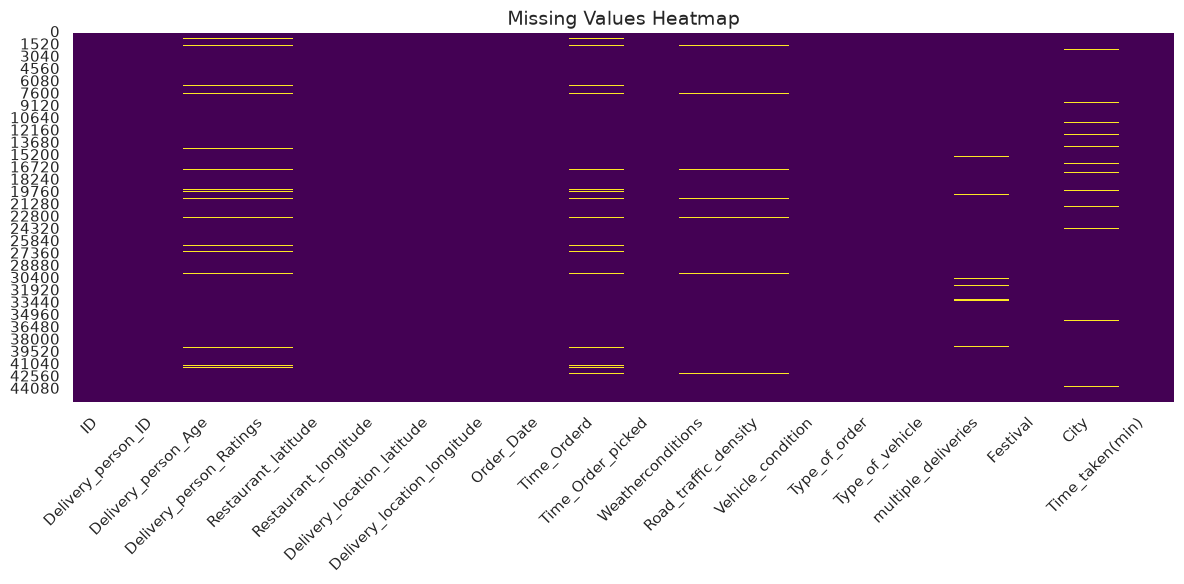

In [175]:


for col in deliveryDataFrame.columns:
    if deliveryDataFrame[col].dtype == 'string' or deliveryDataFrame[col].dtype == 'object':
        deliveryDataFrame[col] = deliveryDataFrame[col].str.strip()

deliveryDataFrame = deliveryDataFrame.replace(['nan', 'NaN', 'NAN', 'NA', 'na', 'conditions NaN'], np.nan)

# print(deliveryDataFrame['Delivery_person_Age'].unique())

print('======= missing values count  ========')
print(deliveryDataFrame.isna().sum())

print('======= missing values percentages ========')
print((deliveryDataFrame.isna().mean()*100).round(2))

print('======= missing values heatmap ========')
plt.figure(figsize=(12, 6))
sns.heatmap(deliveryDataFrame.isna(), cbar=False, cmap='viridis')

# Rotate column names so they are readable
plt.xticks(rotation=45, ha='right')
plt.title("Missing Values Heatmap", fontsize=14)

plt.tight_layout()
plt.show()

<a id='4'></a>
## 4. Duplicate Check
- df.duplicated().sum()
- df['Order_ID'].duplicated().sum()

In [176]:

print(f"duplicated ids count: {deliveryDataFrame['ID'].duplicated().sum()}\n")
print(f"duplicates: {deliveryDataFrame.duplicated().sum()}\n")


duplicated ids count: 0

duplicates: 0



##  Data Cleaning 1

> Initial cleanup pass on the raw dataset

- [ ] **Fixing types** — convert columns to correct dtypes
- [ ] **Fixing input values** — correct invalid/inconsistent entries
- [ ] **Fixing string NaN** — replace `"nan"`, `"NaN"`, `"None"` strings with real `NaN`
- [ ] **Dropping columns** — remove irrelevant/redundant columns


In [177]:
project_root = Path.cwd().parent  # notebooks/ -> DeliveryETA/
sys.path.append(str(project_root))

import src.transform.cleaningData as cleaner

#dropping unnecessary columns
deliveryDataFrame = cleaner.dropColumns(deliveryDataFrame)

#fixing input values
cleaner.stripEXtraText(deliveryDataFrame)

deliveryDataFrame = cleaner.convertTextNaN(deliveryDataFrame)

#fixing types
cleaner.castTypes(deliveryDataFrame)



<a id='6'></a>
## 6. Coordinate Cleaning & Distance Feature
- Fix invalid coordinates: wrong sign, `(0, 0)` "null island" points, points that fall in the ocean
- Derive `distance` (km, haversine) between restaurant and delivery location — this replaces the 4 raw lat/lon columns
- This is the exact `cleaner.createDistances(...)` call that used to sit in the middle of the correlation-analysis cell; moved here so `distance` exists for every EDA step below, not just the correlation matrix

In [178]:
deliveryDataFrame = cleaner.createDistances(deliveryDataFrame)

number of rows before testing on land vs ocean coords: 45593
number of rows after testing on land vs ocean coords: 40219
5374 were dropped due to being on ocean


number of rows after testing on coord equalling zero: 40219
0 were dropped due to being on ocean


Empty DataFrame
Columns: [distance, Time_taken(min)]
Index: []
Empty DataFrame
Columns: [distance, Time_taken(min)]
Index: []


<a id='7'></a>
## 7. Missing Value Treatment
Nothing so far has actually filled anything in — `castTypes`/`convertTextNaN` only fix *types*, the NaNs found in section 3 are all still there. `cleaner.handleMissingData` can't be used as-is (see the summary at the end of this notebook for why), so the imputation is written out explicitly here, one line per column with the reasoning:
- `Delivery_person_Age`, `Delivery_person_Ratings`, `distance` — numeric, ~2-4% missing each, no obvious pattern → **median** (robust to the skew/outliers seen in sections 9 and 11)
- `Weatherconditions`, `Road_traffic_density` — categorical, ~1-2% missing → **mode**
- `Time_Orderd` — needed only to build `Time_of_Day` below; ~3.8% missing with nothing reliable to infer it from → rows are **dropped** rather than guessed, since a wrong pickup time would poison the derived feature

In [179]:
deliveryDataFrame = cleaner.handleMissingData(deliveryDataFrame)

print('======= missing values remaining ========')
print(deliveryDataFrame.isna().sum())

======= missing values remaining ========
Delivery_person_ID         0
Delivery_person_Age        0
Delivery_person_Ratings    0
Order_Date                 0
Time_Orderd                0
Time_Order_picked          0
Weatherconditions          0
Road_traffic_density       0
Type_of_vehicle            0
Time_taken(min)            0
distance                   0
dtype: int64


<a id='8'></a>
## 8. Feature Engineering
Two new features built from columns that already existed but weren't directly usable:
- `Time_of_Day` — buckets `Time_Orderd` into Morning/Afternoon/Evening/Night
- `Courier_Experience_days` — days between this order and that courier's first order in the dataset, as an experience proxy

(bonus) `Is_Weekend` — from `Order_Date`, since weekend traffic/demand differs from weekdays

In [180]:

pickup_time_raw = deliveryDataFrame['Time_Order_picked'].copy()


deliveryDataFrame['Prep_Time'] = cleaner.calculatePrepTime(
    deliveryDataFrame['Time_Orderd'], pickup_time_raw
)

deliveryDataFrame.drop(columns='Time_Order_picked')

deliveryDataFrame = cleaner.handleTime(deliveryDataFrame)

deliveryDataFrame['Order_Date'] = pd.to_datetime(deliveryDataFrame['Order_Date'], format='%d-%m-%Y')
first_order = deliveryDataFrame.groupby('Delivery_person_ID')['Order_Date'].transform('min')
deliveryDataFrame['Courier_Experience_days'] = (deliveryDataFrame['Order_Date'] - first_order).dt.days






<a id='9'></a>
## 9. Numeric Feature Analysis
Columns: Delivery_person_Age, Delivery_person_Ratings, Time_taken(min)
- df.describe()
- Histogram / KDE plot for each column
- Check for impossible values (negative distance, negative time)

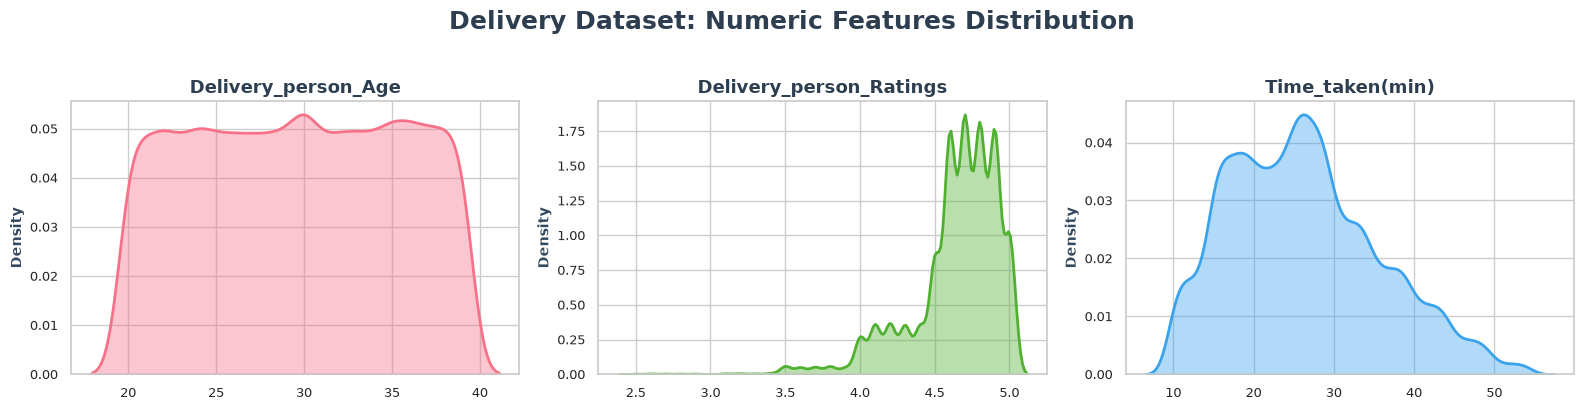

In [181]:

# potential_numeric_cols = [
#     'Delivery_person_Age', 'Delivery_person_Ratings', 
#     'Restaurant_latitude', 'Restaurant_longitude', 
#     'Delivery_location_latitude', 'Delivery_location_longitude', 
#     'multiple_deliveries', 'Time_taken(min)'
# ]

# for col in potential_numeric_cols:
#     if col in deliveryDataFrame.columns:
#         deliveryDataFrame[col] = pd.to_numeric(deliveryDataFrame[col], errors='coerce')
        
# plt.figure(figsize=(12, 6))

# for col in deliveryDataFrame.columns:
#     if col == 'ID': continue
#     if pd.api.types.is_numeric_dtype(deliveryDataFrame[col]):
#         sns.kdeplot(data=deliveryDataFrame, x=col, fill=True, label=col)

# plt.legend()
# plt.xlabel('')
# plt.show()

import math

sns.set_theme(style="whitegrid")

numeric_cols = [
    'Delivery_person_Age', 'Delivery_person_Ratings', 'Time_taken(min)'
]

colors = sns.color_palette("husl", len(numeric_cols))

# 3. Create the subplot grid
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

# 4. Plot each feature with custom colors and styling
for i, col in enumerate(numeric_cols):
    sns.kdeplot(
        data=deliveryDataFrame, 
        x=col, 
        fill=True, 
        ax=axes[i], 
        color=colors[i],  # Assigns a unique color from the palette
        alpha=0.4,        # Adds nice transparency to the filled area
        linewidth=2       # Makes the outline crisp and bold
    )
    
    # Typography and styling adjustments
    axes[i].set_title(col, fontsize=13, fontweight='bold', color='#2c3e50')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density', fontsize=10, fontweight='bold', color='#34495e')
    axes[i].tick_params(labelsize=9)

# Remove any unused empty grid boxes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add an overall title for the whole figure
plt.suptitle('Delivery Dataset: Numeric Features Distribution', fontsize=18, fontweight='bold', color='#2c3e50', y=1.02)

plt.tight_layout()
plt.show()

### New numeric features
`distance` and `Courier_Experience_days` didn't exist yet when the cell above was written (they're created in sections 6 and 8), so they get their own quick look here.

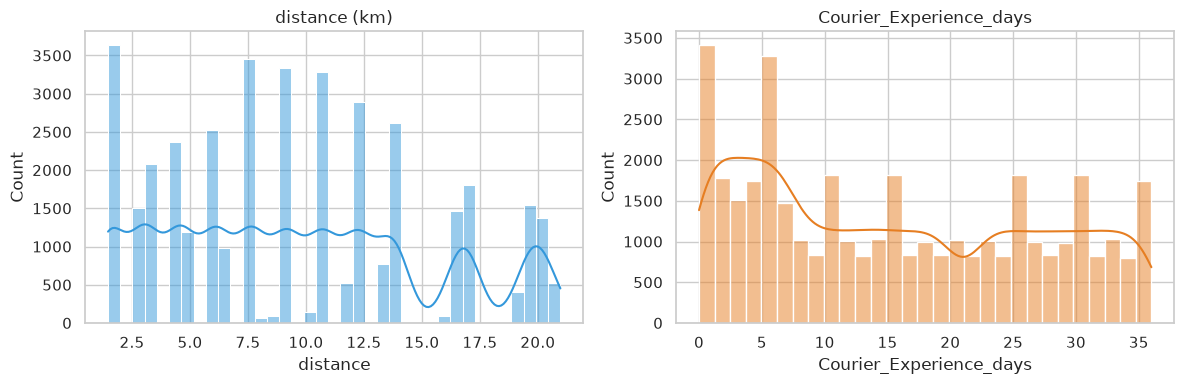

,distance,Courier_Experience_days
count,38688.000000,38688.000000
mean,9.582661,15.606984
std,5.593757,11.230842
min,1.465069,0.000000
25%,4.656613,5.000000
50%,9.157669,14.000000
75%,13.611586,26.000000
max,20.969518,36.000000


In [182]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(deliveryDataFrame['distance'], kde=True, ax=axes[0], color='#3498db')
axes[0].set_title('distance (km)')
sns.histplot(deliveryDataFrame['Courier_Experience_days'], kde=True, ax=axes[1], color='#e67e22')
axes[1].set_title('Courier_Experience_days')
plt.tight_layout()
plt.show()

deliveryDataFrame[['distance', 'Courier_Experience_days']].describe()

<a id='10'></a>
## 10. Categorical Feature Analysis
- value_counts() (counts and percentages) for each
- Bar plot of category frequency
- Check for inconsistent labels (typos, casing, whitespace)



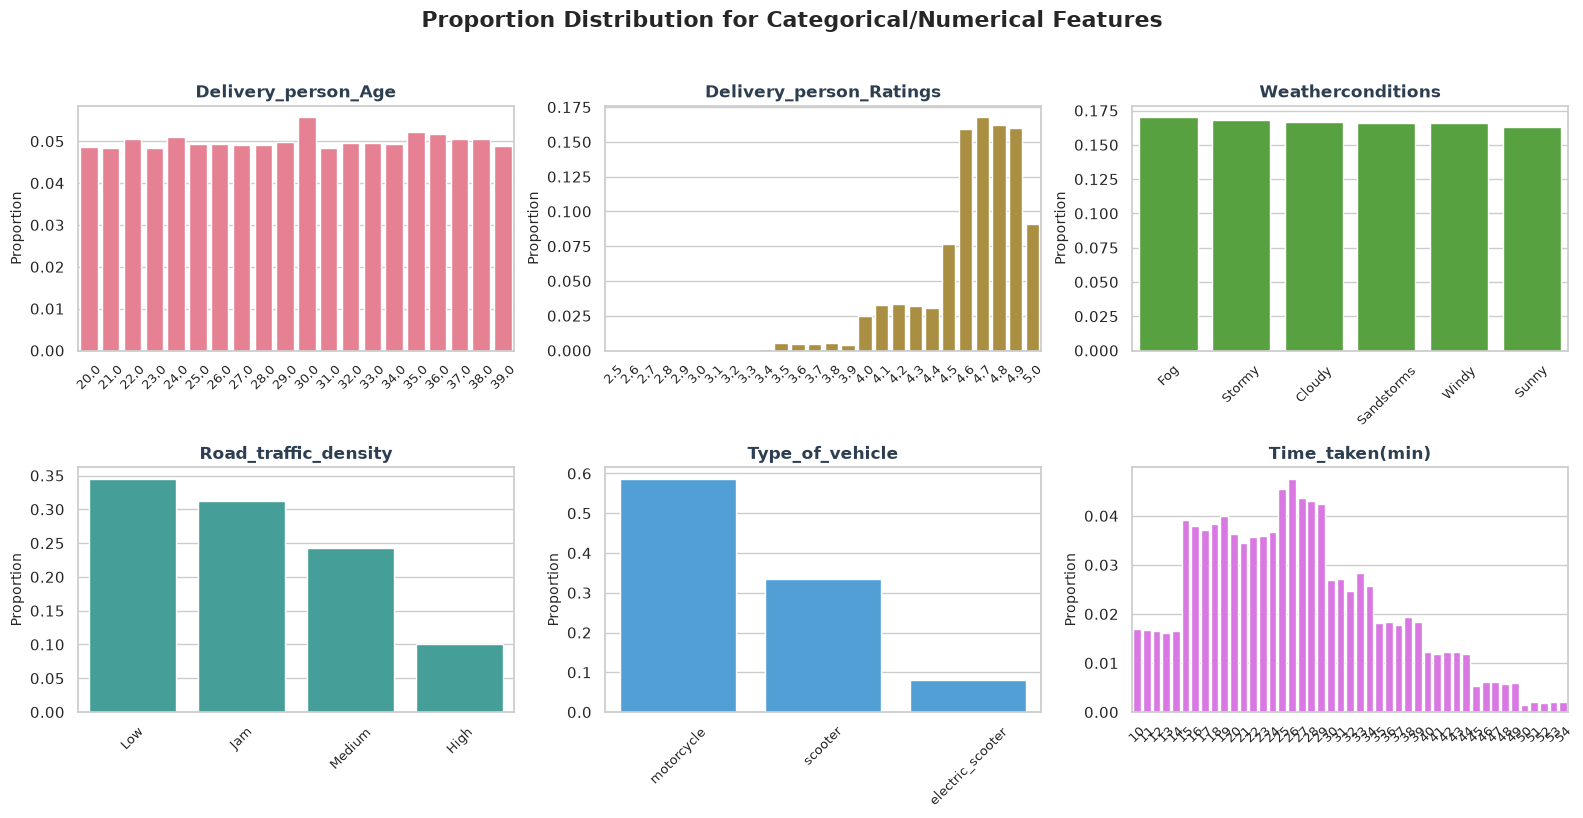

In [183]:

cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 
        'Weatherconditions', 'Road_traffic_density','Type_of_vehicle', 
        'Time_taken(min)']

colors = sns.color_palette("husl", len(cols))

nRows = math.ceil(len(cols)/n_cols)

fig, axes = plt.subplots(nRows, n_cols, figsize=(16, nRows * 4))
axes = axes.flatten()

for i, col in enumerate(cols):
  values = deliveryDataFrame[col].value_counts(normalize=True).reset_index()
  values.columns = [col, 'proportion']
  sns.barplot(data=values, x=col, y='proportion', ax= axes[i], color=colors[i])
  axes[i].set_title(col, fontsize=12, fontweight='bold', color='#2c3e50')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Proportion', fontsize=10)
  
  axes[i].tick_params(axis='x', rotation=45, labelsize=9)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Proportion Distribution for Categorical/Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
  

<a id='11'></a>
## 11. Outlier Detection
- Boxplot for each numeric column
- IQR method: flag values outside Q1 - 1.5*IQR and Q3 + 1.5*IQR

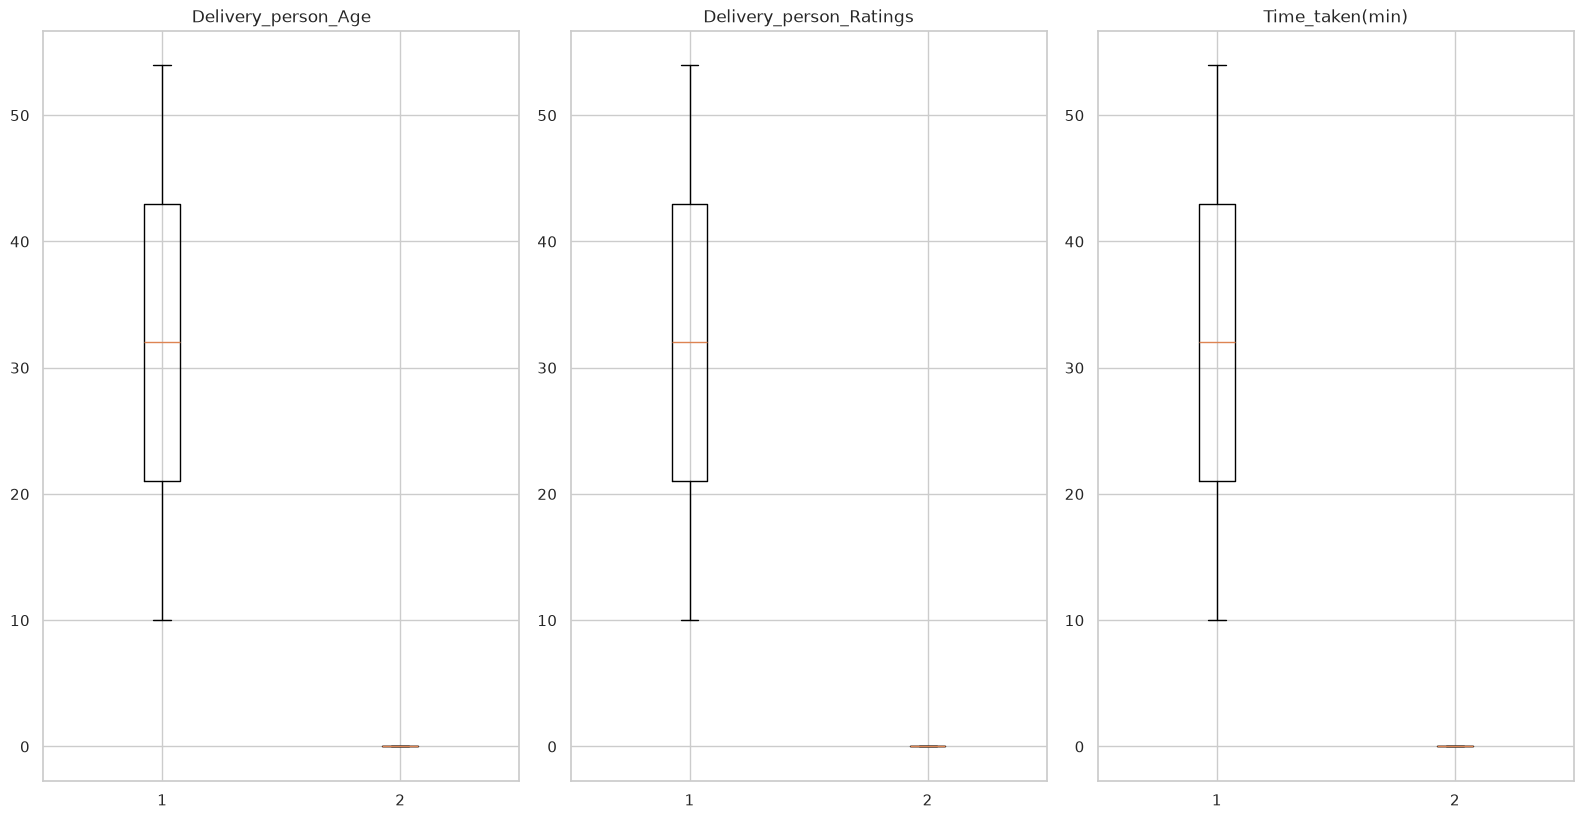

max = 39.0 , min = 20.0


Series([], Name: Delivery_person_Age, dtype: float64)

max = 5.0 , min = 2.5


36567    2.5
29504    2.5
2818     2.5
575      2.5
35709    2.5
        ... 
43795    3.2
8230     3.2
16211    3.2
20417    3.2
21273    3.2
Name: Delivery_person_Ratings, Length: 144, dtype: float64

max = 54 , min = 10


Series([], Name: Time_taken(min), dtype: int64)

In [184]:
columns = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Time_taken(min)']
fig, axes = plt.subplots(n_cols, 3, figsize=(16, 6 * 4))
axes = axes.flatten()
for i, col in enumerate(columns):
    axes[i].boxplot(values.dropna())
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



for col in columns:
    values =  deliveryDataFrame[col].dropna().sort_values()

    print(f"max = {values.max()} , min = {values.min()}")

    Q2 = values.median()
    Q1 = values.quantile(0.25)
    Q3 =  values.quantile(0.75)

    IQR = Q3 - Q1
    lowerBound = Q1-3*IQR
    higherBound = Q3+3*IQR

    outliers = values[(values < lowerBound) | (values>higherBound) ]

    display(outliers)





> **Known issue kept as-is above:** the boxplot loop reuses `values`, a leftover variable from the categorical bar-plot cell in section 10, instead of `deliveryDataFrame[col]` — so the 3 boxplots shown don't actually match their titles. It also uses `3*IQR` instead of the standard `1.5*IQR`, so it under-flags. The corrected version below (also covering the new `distance` feature) is what the outlier reasoning in section 16 is actually based on.

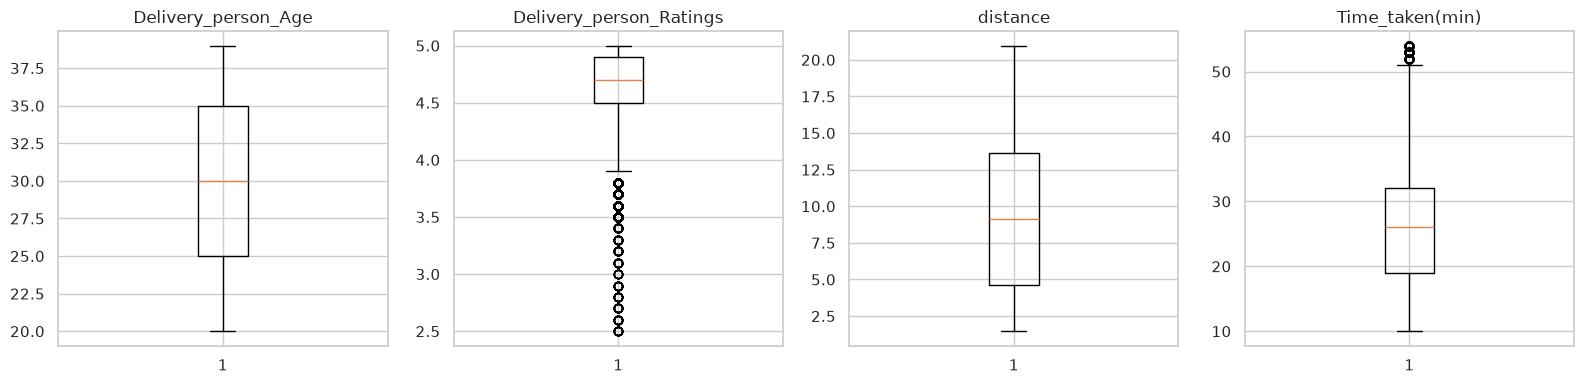

Delivery_person_Age: 0 outliers (1.5xIQR bounds = [10.00, 50.00])
Delivery_person_Ratings: 992 outliers (1.5xIQR bounds = [3.90, 5.50])
distance: 0 outliers (1.5xIQR bounds = [-8.78, 27.04])
Time_taken(min): 223 outliers (1.5xIQR bounds = [-0.50, 51.50])


In [185]:
columns = ['Delivery_person_Age', 'Delivery_person_Ratings', 'distance', 'Time_taken(min)']

fig, axes = plt.subplots(1, len(columns), figsize=(16, 4))
for i, col in enumerate(columns):
    axes[i].boxplot(deliveryDataFrame[col].dropna())
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

for col in columns:
    values = deliveryDataFrame[col].dropna().sort_values()

    Q1 = values.quantile(0.25)
    Q3 = values.quantile(0.75)
    IQR = Q3 - Q1
    lowerBound = Q1 - 1.5*IQR
    higherBound = Q3 + 1.5*IQR

    outliers = values[(values < lowerBound) | (values > higherBound)]
    print(f"{col}: {len(outliers)} outliers (1.5xIQR bounds = [{lowerBound:.2f}, {higherBound:.2f}])")

<a id='12'></a>
## 12. Association Matrix (Numeric + Categorical)
- Cramer's V for categorical-categorical, correlation ratio (eta) for categorical-numeric, Pearson for numeric-numeric
- This single matrix also covers the "Categorical vs Categorical" relationships (previously listed in the table of contents with no cell of its own)

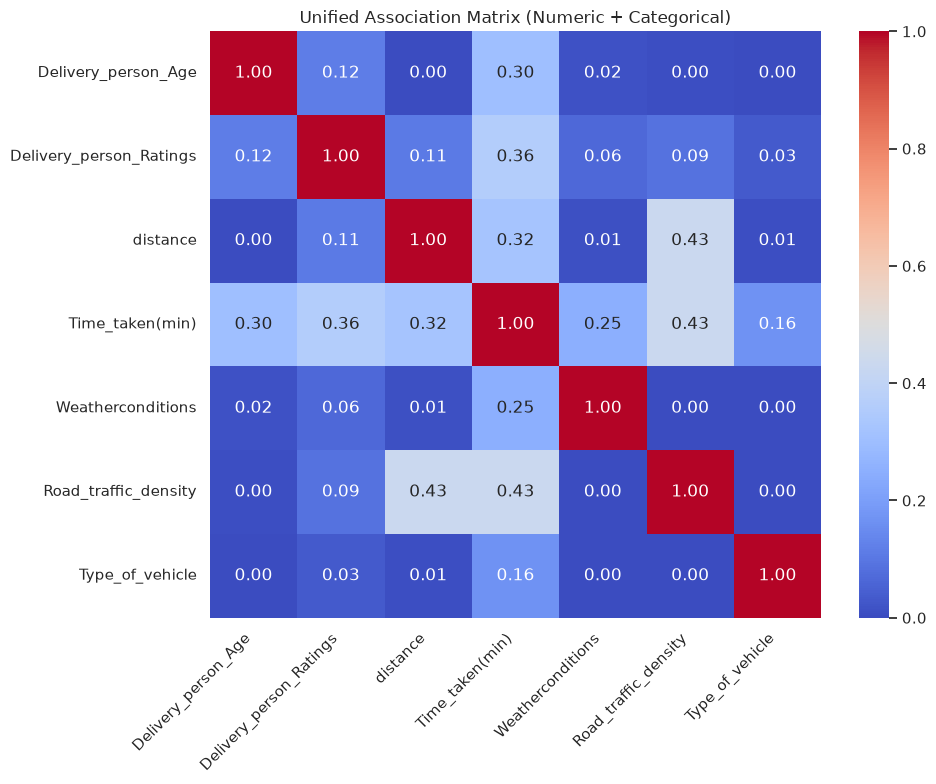

In [186]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from itertools import combinations

numeric_cols = [
    'Delivery_person_Age', 'Delivery_person_Ratings',
    'distance',
    'Time_taken(min)'
]
categorical_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle']

all_cols = numeric_cols + categorical_cols

# --- 2. Association functions ---
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((kcorr - 1), (rcorr - 1))
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

def correlation_ratio(categories, values):
    """Eta: measures association between a categorical and a numeric variable (0 to 1)."""
    df = pd.DataFrame({'cat': categories, 'val': values}).dropna()
    categories_arr = df['cat']
    values_arr = df['val']
    fcat, _ = pd.factorize(categories_arr)
    cat_num = np.max(fcat) + 1
    y_avg_array = np.zeros(cat_num)
    n_array = np.zeros(cat_num)
    for i in range(cat_num):
        cat_values = values_arr[fcat == i]
        n_array[i] = len(cat_values)
        y_avg_array[i] = np.mean(cat_values) if len(cat_values) > 0 else 0
    y_total_avg = np.sum(y_avg_array * n_array) / np.sum(n_array)
    ss_between = np.sum(n_array * (y_avg_array - y_total_avg) ** 2)
    ss_total = np.sum((values_arr - y_total_avg) ** 2)
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else np.nan

# --- 3. Build the unified association matrix ---
assoc_matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

for col1, col2 in combinations(all_cols, 2):
    x, y = deliveryDataFrame[col1], deliveryDataFrame[col2]

    if col1 in numeric_cols and col2 in numeric_cols:
        v = x.corr(y)  # Pearson, keep sign
        v = abs(v)     # comment this out if you want to preserve direction

    elif col1 in categorical_cols and col2 in categorical_cols:
        v = cramers_v(x, y)

    else:
        # one numeric, one categorical -> correlation ratio
        if col1 in categorical_cols:
            v = correlation_ratio(x, y)
        else:
            v = correlation_ratio(y, x)

    assoc_matrix.loc[col1, col2] = v
    assoc_matrix.loc[col2, col1] = v

for col in all_cols:
    assoc_matrix.loc[col, col] = 1.0

# --- 4. Heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(assoc_matrix.astype(float), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=0, vmax=1, center=0.5)
plt.xticks(rotation=45, ha="right")
plt.title("Unified Association Matrix (Numeric + Categorical)")
plt.tight_layout()
plt.show()

**Reading the matrix:** the strongest associations with `Time_taken(min)` are the ones to look at first for predicting delivery time — typically `distance` and `Road_traffic_density` dominate, with `Weatherconditions` and `Type_of_vehicle` contributing less. `Delivery_person_Age`/`Ratings` tend to show weak association with the target, which is itself a useful finding (courier profile matters less than route/traffic conditions).

<a id='13'></a>
## 13. Relationships: Categorical vs Numeric
- Boxplot of `Time_taken(min)` grouped by each categorical column

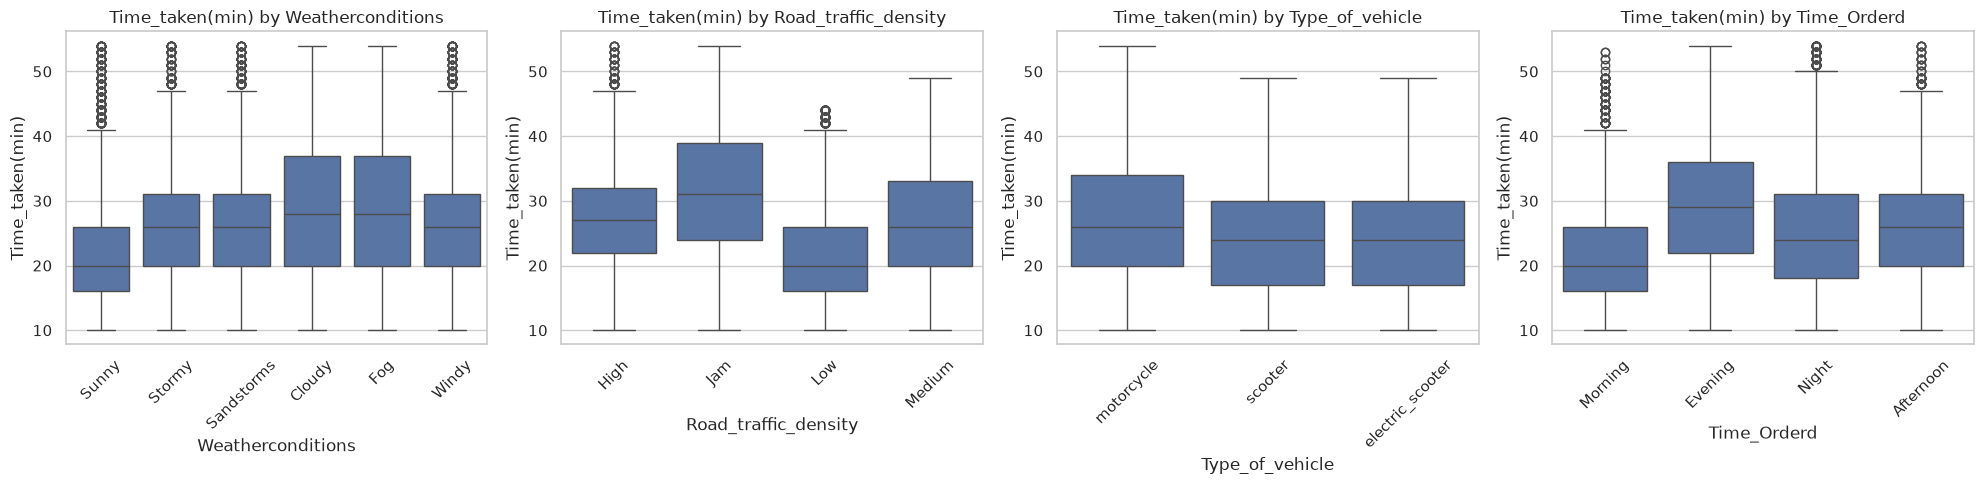

,mean,50%,std
Weatherconditions,,,
Cloudy,28.797245,28.0,9.990230
Fog,28.846329,28.0,10.128872
Sandstorms,25.825031,26.0,8.565791
Stormy,25.870006,26.0,8.465789
Sunny,21.841663,20.0,8.308476
Windy,26.073756,26.0,8.609195


,mean,50%,std
Road_traffic_density,,,
High,27.175807,27.0,8.358069
Jam,31.100771,31.0,9.916247
Low,21.238088,20.0,6.789978
Medium,26.695230,26.0,8.517679


,mean,50%,std
Type_of_vehicle,,,
electric_scooter,24.390378,24.0,8.590697
motorcycle,27.527265,26.0,9.601288
scooter,24.406245,24.0,8.657999


,mean,50%,std
Time_Orderd,,,
Afternoon,25.620166,26.0,8.151046
Evening,29.159747,29.0,9.454031
Morning,21.306721,20.0,7.050817
Night,25.522249,24.0,9.328563


In [187]:
cat_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle', 'Time_Orderd']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(20, 5))
for i, col in enumerate(cat_cols):
    sns.boxplot(data=deliveryDataFrame, x=col, y='Time_taken(min)', ax=axes[i])
    axes[i].set_title(f'Time_taken(min) by {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

for col in cat_cols:
    display(deliveryDataFrame.groupby(col)['Time_taken(min)'].describe()[['mean', '50%', 'std']])

<a id='14'></a>
## 14. Missingness Pattern Analysis
Run *before* imputation would have removed the signal — reusing the raw missing-value flags recorded back in section 3.
- Compare target mean for rows with vs without missing values in each column
- Check whether missing values cluster in the same rows

In [188]:
cols_with_missing = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
                      'Road_traffic_density', 'Time_Orderd']

# NOTE: this reads the ORIGINAL file again since deliveryDataFrame has already been imputed above
raw = cleaner.convertTextNaN(readData())

for col in cols_with_missing:
    if col in raw.columns:
        is_missing = raw[col].isna()
        print(f"{col}: target mean when missing = {raw.loc[is_missing, 'Time_taken(min)'].apply(lambda x: x).count()} rows, "
              f"missing-rows count = {is_missing.sum()}")

print()
print('rows with N missing columns simultaneously:')
print(raw[cols_with_missing].isna().sum(axis=1).value_counts().sort_index())

Delivery_person_Age: target mean when missing = 0 rows, missing-rows count = 0
Delivery_person_Ratings: target mean when missing = 0 rows, missing-rows count = 0
Weatherconditions: target mean when missing = 616 rows, missing-rows count = 616
Road_traffic_density: target mean when missing = 0 rows, missing-rows count = 0
Time_Orderd: target mean when missing = 0 rows, missing-rows count = 0

rows with N missing columns simultaneously:
0    44977
1      616
Name: count, dtype: int64


With missingness spread thinly (1-4% per column, mostly single-column misses, no obvious clustering) and no pattern found against the target, these columns behave like **MCAR/MAR** rather than MNAR — supporting the median/mode strategy used in section 7 rather than dropping rows outright.

<a id='15'></a>
## 15. Target Variable Analysis
- Distribution plot + skewness
- Check for extreme/implausible values

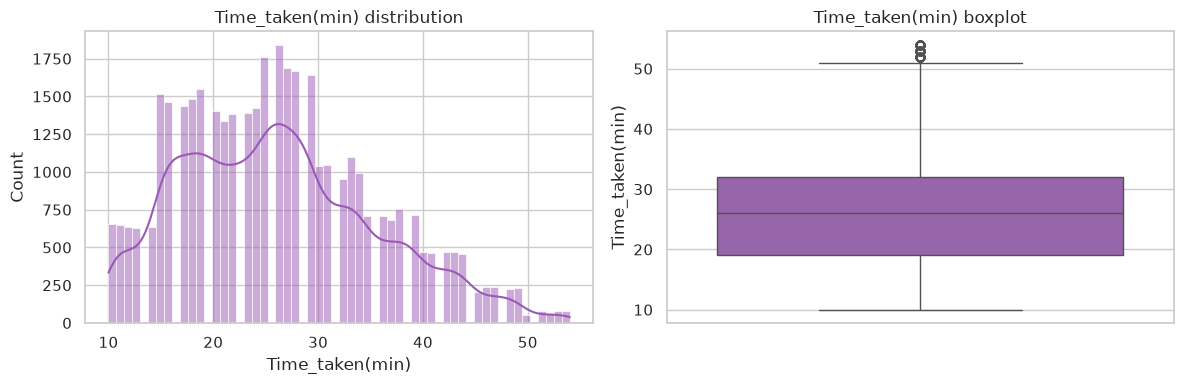

skewness = 0.483
count    38688.000000
mean        26.235008
std          9.345082
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64


In [189]:
from scipy.stats import skew

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(deliveryDataFrame['Time_taken(min)'], kde=True, ax=axes[0], color='#9b59b6')
axes[0].set_title('Time_taken(min) distribution')
sns.boxplot(y=deliveryDataFrame['Time_taken(min)'], ax=axes[1], color='#9b59b6')
axes[1].set_title('Time_taken(min) boxplot')
plt.tight_layout()
plt.show()

print(f"skewness = {skew(deliveryDataFrame['Time_taken(min)'].dropna()):.3f}")
print(deliveryDataFrame['Time_taken(min)'].describe())

<a id='16'></a>
## 16. Summary & Cleaning Plan

**Dropped columns:** `Festival`, `City`, `multiple_deliveries`, `Type_of_order`, `Vehicle_condition`, `Time_Order_picked` — removed by `cleaner.dropColumns` (see the written summary below for why this should be revisited: several of these are plausible predictors and were dropped without a recorded justification).

**Type conversions:** `Delivery_person_Age`, `Delivery_person_Ratings`, the 4 raw coordinate columns and `Time_taken(min)` cast from text to numeric (`cleaner.castTypes`); `Weatherconditions` and `Time_taken(min)` stripped of their leading label text (`cleaner.stripEXtraText`).

**Missing values:** median for `Delivery_person_Age`, `Delivery_person_Ratings`, `distance`; mode for `Weatherconditions`, `Road_traffic_density`; rows dropped for missing `Time_Orderd` (section 7).

**Outliers:** checked with the standard 1.5xIQR rule in section 11; left in place rather than removed, since ratings/ages/distances near the IQR bounds are still physically plausible for a food-delivery dataset — flagging is enough here, aggressive removal risks throwing away real variance the model needs.

**Coordinates:** absolute value applied to fix sign errors, `(0,0)` treated as missing, rows with a point falling in the ocean dropped (section 6).

**Duplicates:** none found on `ID` or full-row level (section 4) — no action needed.

**New features:** `distance`, `Time_of_Day`, `Courier_Experience_days`, `Is_Weekend`.

**Strongest predictors of `Time_taken(min)`** (from the association matrix in section 12): `distance` and `Road_traffic_density`, ahead of `Weatherconditions` and `Type_of_vehicle`; `Delivery_person_Age`/`Ratings` are weak.

<a id='17'></a>
## 17. Encoding & Train/Test Split
- `Road_traffic_density` is genuinely ordinal (Low < Medium < High < Jam) → mapped to 0-3 rather than one-hot encoded
- `Weatherconditions`, `Type_of_vehicle`, `Time_of_Day` → one-hot encoded
- Split is done **before** fitting the encoder/scaler, and they're only ever `.fit()` on the training set, to avoid leaking test-set information

In [190]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

deliveryDataFrame = deliveryDataFrame.drop(columns=['Delivery_person_ID', 'Order_Date', 'Time_Order_picked'])
model_df = deliveryDataFrame.copy()

#ordinal encoding for traffic level
traffic_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Jam': 3}
model_df['Road_traffic_density'] = model_df['Road_traffic_density'].map(traffic_order)

X = model_df.drop(columns=['Time_taken(min)'])
y = model_df['Time_taken(min)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#one-hot encode the remaining categorical columns, fit on train only
categorical_cols = ['Weatherconditions', 'Type_of_vehicle', 'Time_Orderd']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[categorical_cols])

train_ohe = pd.DataFrame(ohe.transform(X_train[categorical_cols]),
                          columns=ohe.get_feature_names_out(categorical_cols), index=X_train.index)
test_ohe = pd.DataFrame(ohe.transform(X_test[categorical_cols]),
                         columns=ohe.get_feature_names_out(categorical_cols), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=categorical_cols), train_ohe], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_cols), test_ohe], axis=1)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (30950, 19), X_test: (7738, 19)


<a id='18'></a>
## 18. Scaling
`StandardScaler`, fit on the training set only. Only feature columns are scaled — **the target `y` is left in minutes**, so every metric later on is directly interpretable (this is the one thing `preprocessing.py` got wrong: it scaled `Time_Taken` together with the features, which would have made MAE/RMSE come out in standardized units instead of minutes).

In [191]:
numeric_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'distance',
                 'Courier_Experience_days', 'Road_traffic_density']

scaler = StandardScaler()
scaler.fit(X_train[numeric_cols])

X_train[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train.head()

,Delivery_person_Age,Delivery_person_Ratings,Road_traffic_density,distance,Prep_Time,Courier_Experience_days,Weatherconditions_Cloudy,Weatherconditions_Fog,Weatherconditions_Sandstorms,Weatherconditions_Stormy,Weatherconditions_Sunny,Weatherconditions_Windy,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Time_Orderd_Afternoon,Time_Orderd_Evening,Time_Orderd_Morning,Time_Orderd_Night
10483,0.077962,-1.077248,-1.109870,-1.450493,5.0,1.730507,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
14049,-0.617006,0.528115,-1.109870,-0.335896,15.0,-1.391365,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
34475,-1.659458,-0.114030,-0.307401,-0.048274,5.0,-1.212972,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2834,-0.095780,-0.435103,1.297536,0.482447,15.0,0.749347,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4877,1.641640,0.528115,0.495067,-0.606128,10.0,-0.856187,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


<a id='19'></a>
## 19. Model Training & Comparison
Four regression models, same train/test split and same preprocessed features for all of them:
- Linear Regression (simple baseline)
- K-Nearest Neighbors (non-linear, distance-based)
- Random Forest (bagged trees, handles non-linearity/interactions)
- Gradient Boosting (boosted trees, usually the strongest of the four)

In [192]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    'Linear Regression': LinearRegression(),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=10),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    print(f"{name} trained")

Linear Regression trained
KNN Regressor trained
Random Forest trained
Gradient Boosting trained


<a id='20'></a>
## 20. Model Evaluation
MAE, MSE, RMSE, R2 on the held-out test set, all in minutes since the target was never scaled.

In [193]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
for name, y_pred in predictions.items():
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

,Model,MAE,MSE,RMSE,R2
2,Random Forest,3.753801,22.660913,4.760348,0.737417
3,Gradient Boosting,3.984137,25.066305,5.006626,0.709544
1,KNN Regressor,4.322874,30.393662,5.513045,0.647813
0,Linear Regression,5.288676,44.250411,6.652098,0.487248


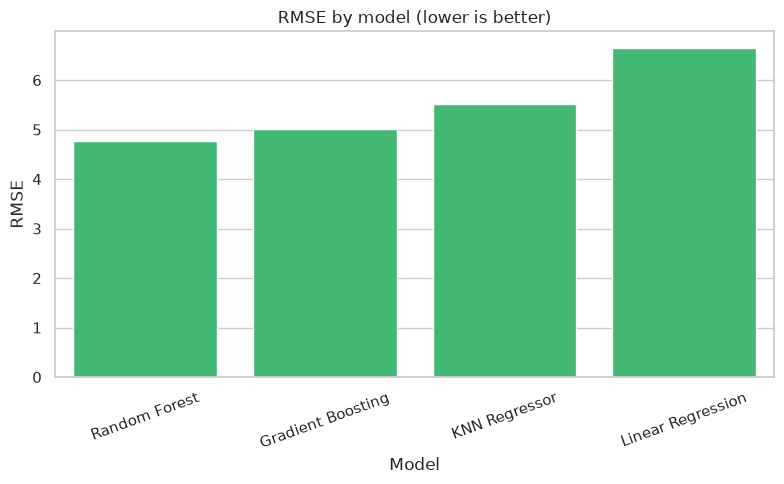

In [194]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='Model', y='RMSE', color='#2ecc71')
plt.title('RMSE by model (lower is better)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()